In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
import tensorboard as tb
import matplotlib.pyplot as plt

I0000 00:00:1791646535.909971   39188 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791646536.001170   39188 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791646538.081595   39188 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv('../dataset/Iisingintie_Acc1_m801_RDMC_2026-05-06_124454.txt', sep='\t')

df.head()

,Num,Timer(ms),Loc(m),Speed (m/s),East(m),North(m),CElev(m),Roll(deg),Pitch(deg),Yaw(deg),...,AccY,AccZ,GyrX,GyrY,GyrZ,RBCSV_80(cf),RBCSV_60(cf),posneg,vaikeus,muu
0,1,"45900476,5","3760,479","0,061","426295,583","7414096,205","109,111","2,0162","-1,828","5,3424",...,"0,35245","9,83279","-0,00746","0,00199","0,00196","7,16884","7,1267",0,0,0
1,2,45900479,"3760,479","0,061","426295,583","7414096,205","109,112","2,0173","-1,8276","5,3428",...,"0,37702","9,83549","0,00233","0,00402","-0,00203","7,16884","7,1267",0,0,0
2,3,45900474,"3760,479","0,061","426295,583","7414096,205","109,111","2,0165","-1,8282","5,3417",...,"0,37302","9,79574","-0,0051","0,00201","0,00173","7,16884","7,1267",0,0,0
3,4,"45900481,5","3760,479","0,061","426295,583","7414096,205","109,112","2,0172","-1,8274","5,3428",...,"0,39893","9,81955","-0,00597","0,00235","-0,00437","7,16884","7,1267",0,0,0
4,5,"45900471,5","3760,479","0,061","426295,583","7414096,205","109,111","2,0165","-1,8283","5,3408",...,"0,38664","9,83676","-0,00245","0,00137","-0,00626","7,16884","7,1267",0,0,0


In [3]:
df = df.drop(columns=['Num'])

In [4]:
df.columns

Index(['Timer(ms)', 'Loc(m)', 'Speed (m/s)', 'East(m)', 'North(m)', 'CElev(m)',
       'Roll(deg)', 'Pitch(deg)', 'Yaw(deg)', 'AccX', 'AccY', 'AccZ', 'GyrX',
       'GyrY', 'GyrZ', 'RBCSV_80(cf)', 'RBCSV_60(cf)', 'posneg', 'vaikeus',
       'muu'],
      dtype='str')

In [5]:
for column in df.columns:
    df[column] = pd.to_numeric(df[column].astype(str).str.replace(",", ".", regex=False))
    print(f"{column} done!")

Timer(ms) done!
Loc(m) done!
Speed (m/s) done!
East(m) done!
North(m) done!
CElev(m) done!
Roll(deg) done!
Pitch(deg) done!
Yaw(deg) done!
AccX done!
AccY done!
AccZ done!
GyrX done!
GyrY done!
GyrZ done!
RBCSV_80(cf) done!
RBCSV_60(cf) done!
posneg done!
vaikeus done!
muu done!


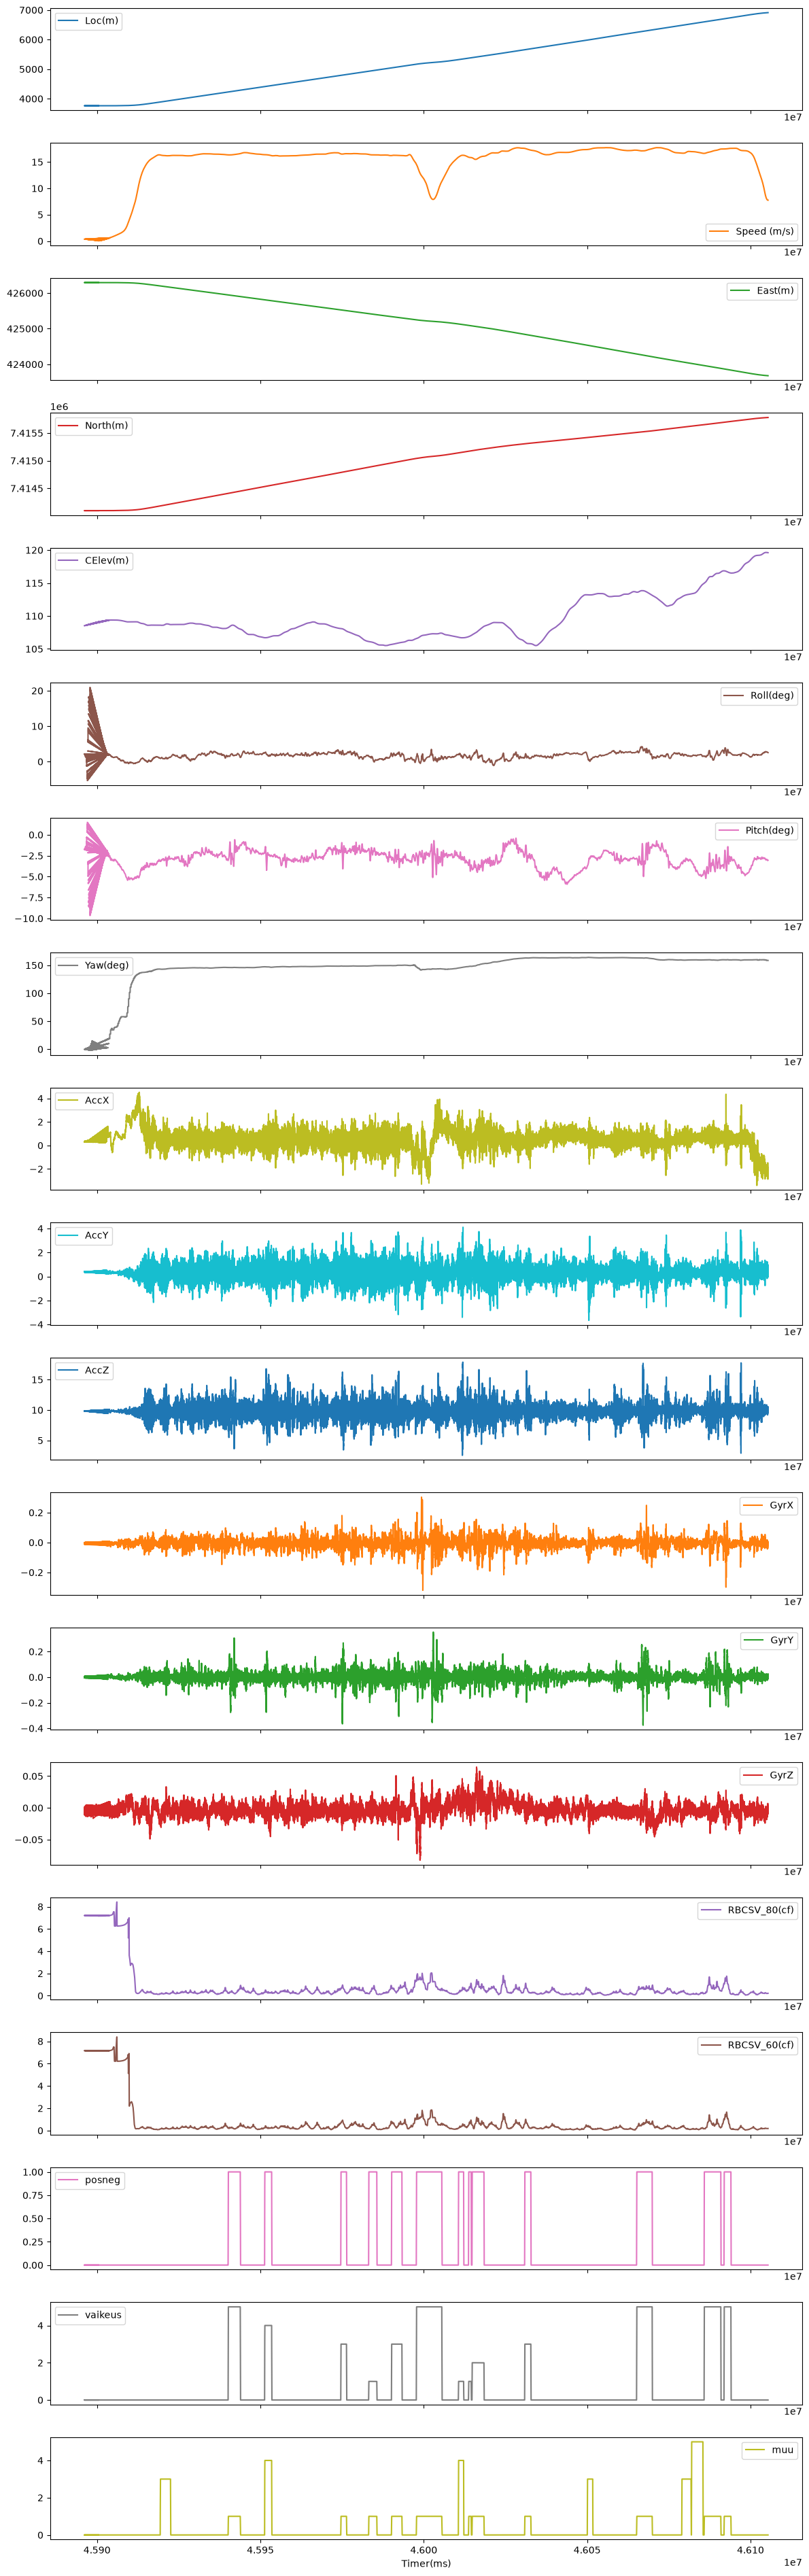

In [6]:
df.plot(x="Timer(ms)", subplots=True, figsize=(12, 2 * (len(df.columns) - 1)), sharex=True)
plt.tight_layout()
plt.show()

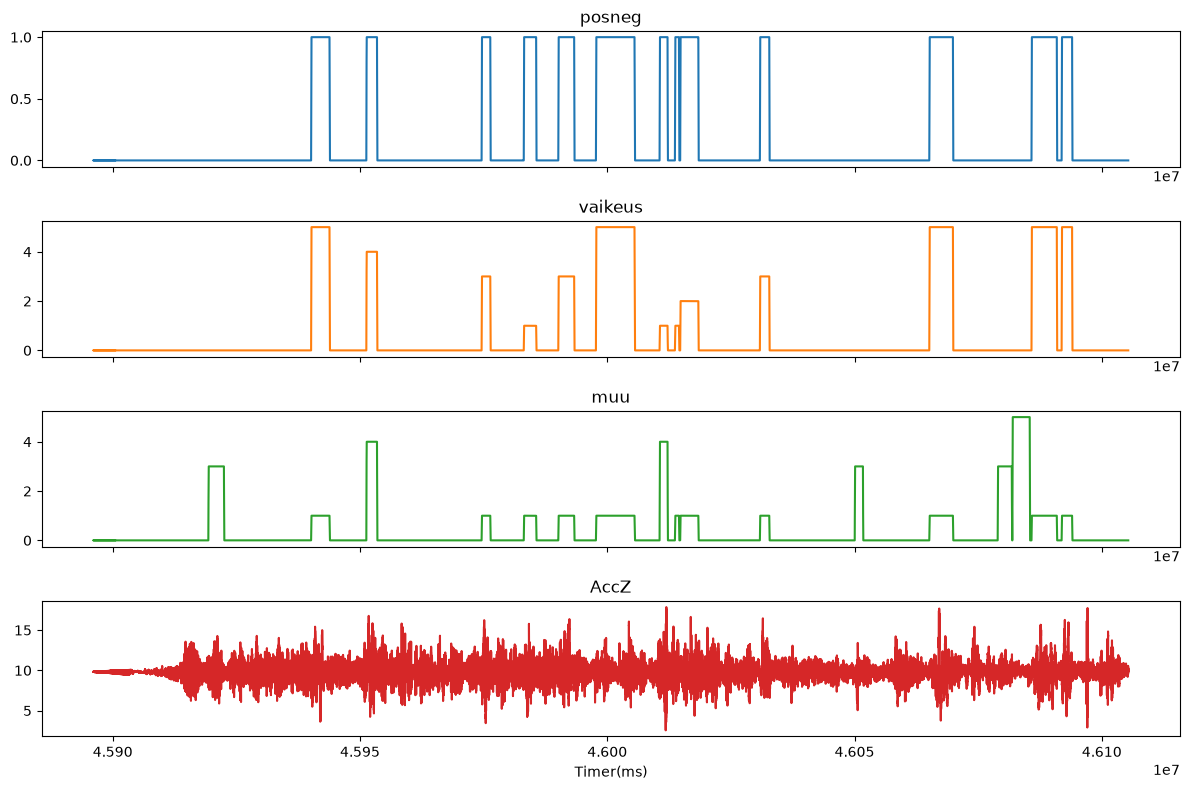

In [7]:
cols = ["posneg", "vaikeus", "muu", "AccZ"]

axes = df.plot(
    x="Timer(ms)",
    y=cols,
    subplots=True,
    figsize=(12, 2 * len(cols)),
    sharex=True,
    legend=False,
    title=cols,
)
plt.tight_layout()
plt.savefig("signalsACCZ2.png", dpi=150)
plt.show()

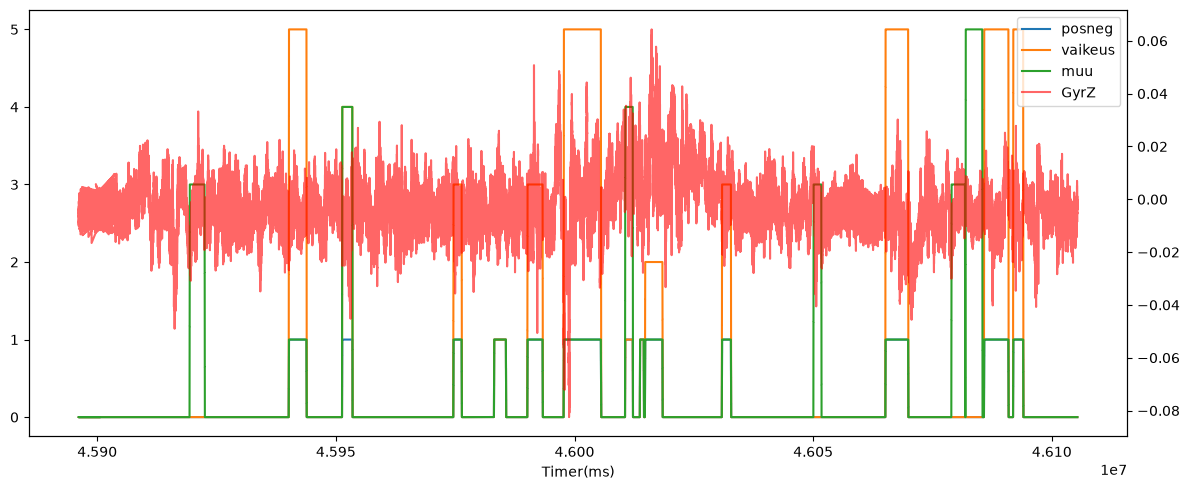

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

for c in ["posneg", "vaikeus", "muu"]:
    ax.plot(df["Timer(ms)"], df[c], label=c, drawstyle="steps-post")

ax2 = ax.twinx()
ax2.plot(df["Timer(ms)"], df["GyrZ"], color="red", alpha=0.6, label="GyrZ")

ax.set_xlabel("Timer(ms)")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right")

plt.tight_layout()
plt.savefig("signalsGYSZ2.png", dpi=150)
plt.show()